# 01 — Exploratory Data Analysis

Dataset C, AMLH coursework. Loads and audits the raw data, characterises class support and
label-space structure, and measures the phrasing-homogeneity gap between the validation
hold-out and the real test set. All logic lives in `src/amlh`; this notebook only calls it,
displays results, and persists figures/tables to `figures/` and `artefacts/`.


In [1]:
from pathlib import Path

import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer

from amlh import eda, features
from amlh.config import ARTEFACTS_DIR, FIGURES_DIR, SEED, set_seed
from amlh.data import load_test, load_train, make_validation_split, run_integrity_audit, save_splits

set_seed()
ARTEFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 170)


## 1. Load, integrity audit, NHS document coverage

In [2]:
train = load_train()
test = load_test()

audit = run_integrity_audit(train, test)
print(json.dumps(audit, indent=2))


{
  "n_train": 8891,
  "n_test": 200,
  "n_classes_train": 906,
  "n_classes_test": 102,
  "test_labels_unseen_in_train": [],
  "class_support": {
    "min": 4,
    "median": 10.0,
    "mean": 9.81,
    "max": 20,
    "sd": 0.98,
    "n_singletons": 0,
    "n_below_5": 1
  },
  "exact_dup_question_disease": 0,
  "duplicate_question_strings": 105,
  "ambiguous_question_strings": 85,
  "labels_in_a_family": 355,
  "largest_families": {
    "baby": 53,
    "pregnancy": 24,
    "social": 23,
    "cosmetic": 20,
    "contraception": 14
  },
  "near_duplication": {
    "frac_cos_ge_0.95": 0.005,
    "frac_cos_ge_0.9": 0.005,
    "frac_cos_ge_0.8": 0.025,
    "frac_cos_ge_0.7": 0.15,
    "median_max_cosine": 0.4852
  }
}


In [3]:
coverage = features.doc_coverage(train.disease.unique())
print(json.dumps(coverage, indent=2))
assert coverage["n_found"] == coverage["n_total"], "NHS document coverage is incomplete"

with open(ARTEFACTS_DIR / "doc_coverage.json", "w") as f:
    json.dump(coverage, f, indent=2)


{
  "n_total": 906,
  "n_found": 906,
  "missing": []
}


In [4]:
split = make_validation_split(train, seed=SEED)
print(f"fit={len(split.fit)} | val={len(split.val)} ({split.val.disease.nunique()} classes) | test={len(test)}")


fit=8691 | val=200 (102 classes) | test=200


## 2. Figure 1 — class support, question length, label families, near-duplication

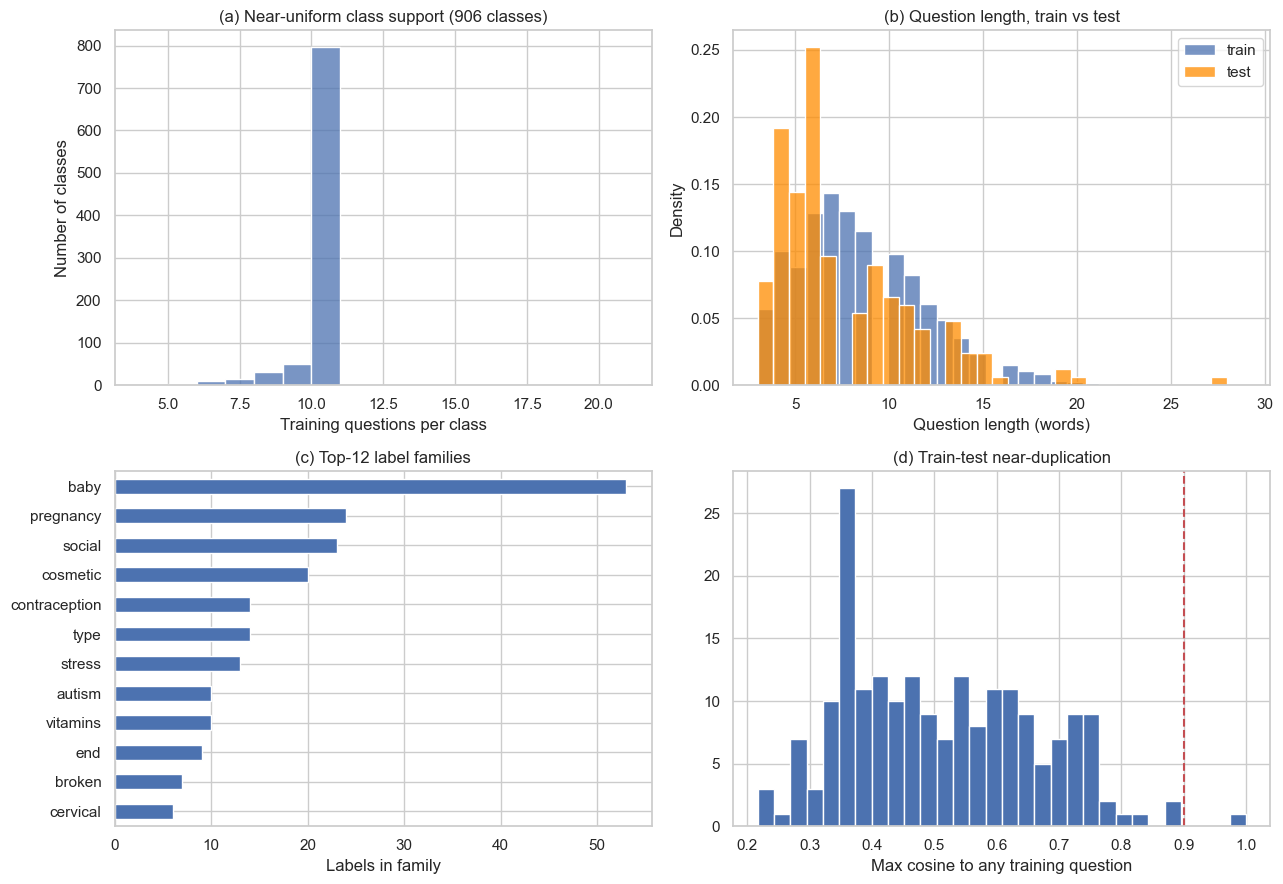

In [5]:
for d in (train, test):
    d["q_len"] = d.question.str.split().str.len()

cnt = train.disease.value_counts()
fam = eda.label_family(pd.Series(sorted(train.disease.unique())))
fam_counts = fam.value_counts()
near_dup_sim = eda.near_duplication_similarities(train, test)

fig, ax = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(cnt.values, bins=range(int(cnt.min()), int(cnt.max()) + 2), ax=ax[0, 0])
ax[0, 0].set(xlabel="Training questions per class", ylabel="Number of classes",
             title=f"(a) Near-uniform class support ({len(cnt)} classes)")

sns.histplot(train.q_len, bins=30, stat="density", ax=ax[0, 1], label="train")
sns.histplot(test.q_len, bins=30, stat="density", ax=ax[0, 1], label="test", color="darkorange")
ax[0, 1].legend()
ax[0, 1].set(xlabel="Question length (words)", title="(b) Question length, train vs test")

fam_counts.head(12).plot.barh(ax=ax[1, 0])
ax[1, 0].invert_yaxis()
ax[1, 0].set(xlabel="Labels in family", title="(c) Top-12 label families")

ax[1, 1].hist(near_dup_sim, bins=30)
ax[1, 1].axvline(0.9, ls="--", c="r")
ax[1, 1].set(xlabel="Max cosine to any training question",
             title="(d) Train-test near-duplication")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig1_eda.png", dpi=150)
plt.show()


## 3. Question-length percentiles (justifies BERT `max_length=48`, §2.2)

In [6]:
q_len_percentiles = train.q_len.describe(percentiles=[.5, .9, .95, .99])
print(q_len_percentiles)
q_len_percentiles.to_csv(ARTEFACTS_DIR / "question_length_percentiles.csv", header=["value"])


count    8891.000000
mean        8.433360
std         3.544181
min         3.000000
50%         8.000000
90%        13.000000
95%        15.000000
99%        18.000000
max        29.000000
Name: q_len, dtype: float64


## 4. Label-family and ambiguity tables

In [7]:
family_sizes = fam_counts.rename_axis("family").reset_index(name="n_labels")
print(family_sizes.head(12))
family_sizes.to_csv(ARTEFACTS_DIR / "label_family_sizes.csv", index=False)


           family  n_labels
0            baby        53
1       pregnancy        24
2          social        23
3        cosmetic        20
4   contraception        14
5            type        14
6          stress        13
7          autism        10
8        vitamins        10
9             end         9
10         broken         7
11       cervical         6


In [8]:
examples = eda.ambiguous_examples(train, n=4)
for ex in examples:
    print(f"  '{ex['question']}' -> {ex['diseases']}")

pd.DataFrame(examples).to_csv(ARTEFACTS_DIR / "ambiguous_examples.csv", index=False)


  'How can I know if I've reached menopause while on the pill?' -> ['contraception_pill_sick_vomit_diarrhoea', 'contraception_taken_extra_pill_by_accident']
  'How can I tell if my baby is getting enough milk during breastfeeding?' -> ['baby_support_and_services_tips_for_new_parents', 'pregnancy_and_baby_breastfeeding_is_baby_getting_enough_milk', 'pregnancy_and_baby_breastfeeding_positioning_attachment']
  'How effective is emergency contraception?' -> ['contraception_pill_sick_vomit_diarrhoea', 'contraception_taken_extra_pill_by_accident']
  'How often should I change my baby's nappy?' -> ['baby_caring_for_a_newborn_how_to_change_your_babys_nappy', 'baby_support_and_services_tips_for_new_parents']


## 5. Sibling-homogeneity measurement

**Declared exception (CLAUDE.md hard rule #2).** The two cells below read `test.disease` to
characterise the validation-test relationship — sibling phrasing homogeneity and the
novelty-calibration target. This is a distributional diagnostic; it selects no model,
hyperparameter, preprocessing setting, or index variant.


In [9]:
homogeneity = eda.sibling_homogeneity(train, test)
print(homogeneity.summary)

wrong_closer = eda.wrong_class_closer_fraction(homogeneity.own, homogeneity.other)
print(f"\nwrong class closer for {wrong_closer:.1%} of test questions")

homogeneity.summary.to_csv(ARTEFACTS_DIR / "sibling_homogeneity.csv", index=False)


                                          comparison  mean_cosine
0       train question -> nearest same-class sibling        0.572
1  test question -> nearest own-class train question        0.391
2  test question -> nearest other-class train que...        0.510

wrong class closer for 59.5% of test questions


## 6. Figure 2 — novelty distributions

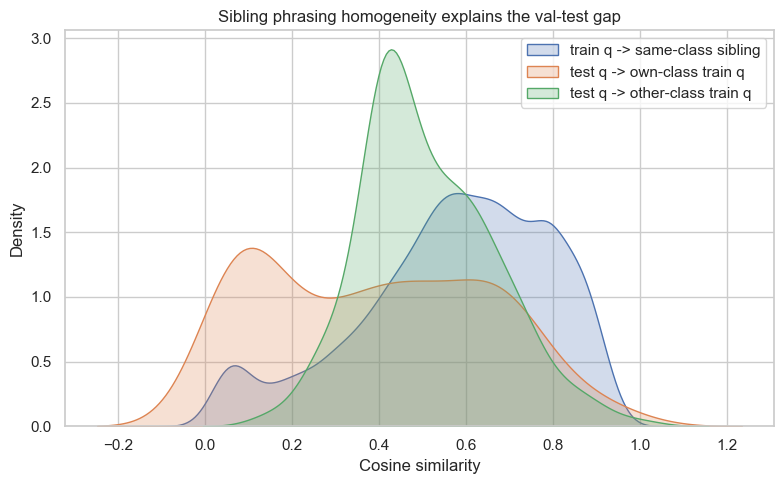

In [10]:
plt.figure(figsize=(8, 5))
sns.kdeplot(homogeneity.sib, label="train q -> same-class sibling", fill=True)
sns.kdeplot(homogeneity.own, label="test q -> own-class train q", fill=True)
sns.kdeplot(homogeneity.other, label="test q -> other-class train q", fill=True)
plt.xlabel("Cosine similarity")
plt.title("Sibling phrasing homogeneity explains the val-test gap")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig2_novelty.png", dpi=150)
plt.show()


## 7. Novelty-calibrated validation diagnostic

Pruning near-sibling fit questions from the index until validation novelty matches the test
level recovers a more realistic accuracy estimate. Secondary diagnostic, not the primary
protocol.


In [11]:
test_novelty = round(float(np.median(homogeneity.own)), 3)
print(f"target novelty (test) = {test_novelty}")

rows = []
for t in (1.01, 0.70, 0.60, 0.50, 0.45, 0.40):
    val_accuracy, median_novelty = eda.novelty_calibrated_eval(split.fit, split.val, prune_threshold=t)
    rows.append({"prune_threshold": t, "val_accuracy": val_accuracy, "median_own_class_novelty": median_novelty})

calibration = pd.DataFrame(rows)
print(calibration)
calibration.to_csv(ARTEFACTS_DIR / "novelty_calibration.csv", index=False)


target novelty (test) = 0.382


   prune_threshold  val_accuracy  median_own_class_novelty
0             1.01         0.765                     0.607
1             0.70         0.720                     0.564
2             0.60         0.655                     0.524
3             0.50         0.495                     0.438
4             0.45         0.390                     0.390
5             0.40         0.270                     0.331


## 8. Persist enriched audit and splits

In [12]:
audit["doc_coverage"] = coverage
audit["sibling_homogeneity"] = homogeneity.summary.set_index("comparison").mean_cosine.to_dict()
audit["wrong_class_closer_fraction"] = round(wrong_closer, 4)
audit["test_median_own_class_novelty"] = test_novelty

save_splits(split.fit, split.val, audit)
print("splits and enriched audit saved to artefacts/")


splits and enriched audit saved to artefacts/


## 9. Figure 3 — PCA of TF-IDF question vectors, 10 largest classes

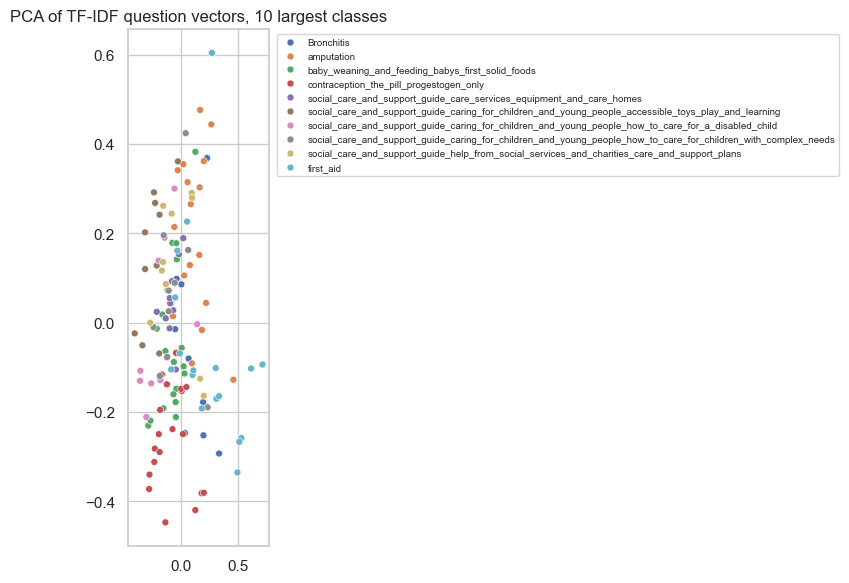

In [13]:
big_classes = cnt.head(10).index
subset = train[train.disease.isin(big_classes)]

vec = TfidfVectorizer(sublinear_tf=True, min_df=2).fit(subset.question)
X_pca_input = vec.transform(subset.question)
pcs = PCA(n_components=2, random_state=SEED).fit_transform(X_pca_input.toarray())

plt.figure(figsize=(8, 6))
sns.scatterplot(x=pcs[:, 0], y=pcs[:, 1], hue=subset.disease.values, s=25)
plt.title("PCA of TF-IDF question vectors, 10 largest classes")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig3_pca.png", dpi=150)
plt.show()
